# Experiment Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import warnings

# Suppress overflow warnings for the exploding standard SGD
warnings.filterwarnings('ignore')

# ==========================================
# 1. Configuration Dictionaries
# ==========================================

exp_config = {
    'q': 0.99999,
    'n_runs': 100,           # Independent trials per cell
    'batch_size': 20,        # Mini-batch size
    'tolerance': 0.05,       # Distance from true VaR to be considered "success"
    'init_grid': np.linspace(-20, 30, 15),
    'lr_grid': np.logspace(-3, 0, 8),
    'clip_val': 40000
}

algo_config_std = {
    'variance_reduce': False,
    'scheme': 'constant',
    'alpha': 0.5,
    'init_multiplier': 1.0,
    'iterations': 4000       # Iteration budget moved here
}

algo_config_is = {
    'variance_reduce': True,
    'scheme': 'constant',
    'alpha': 0.5,
    'init_multiplier': 1.0,
    'iterations': 4000       # Iteration budget moved here
}

# ==========================================
# 2. Experiment Execution Engine
# ==========================================
import numpy as np
from scipy.stats import norm

def run_exp(exp_config, algo_config):
    """Runs the SGD simulation and returns both the heatmap and the full trajectory tensor."""
    q = exp_config['q']
    true_var = norm.ppf(q)
    n_runs = exp_config['n_runs']
    tolerance = exp_config['tolerance']
    clip_val = exp_config['clip_val']

    init_grid = exp_config['init_grid']
    lr_grid = exp_config['lr_grid']

    variance_reduce = algo_config['variance_reduce']
    scheme = algo_config.get('scheme', 'last')
    alpha = algo_config['alpha']
    init_multiplier = algo_config['init_multiplier']
    iterations = algo_config['iterations']
    batch_size = algo_config['batch_size']

    # NEW: Define how much of the early trajectory to throw away (default to 50%)
    burn_in_fraction = algo_config.get('burn_in_fraction', 0.5)
    burn_in_steps = int(iterations * burn_in_fraction)

    # Pre-allocate memory
    heatmap_results = np.zeros((len(lr_grid), len(init_grid)))
    trajectories = np.zeros((len(lr_grid), len(init_grid), iterations, n_runs))

    print(f"Running | VR: {variance_reduce} | Scheme: {scheme} | Iterations: {iterations} | Burn-in: {burn_in_steps}")

    for i, lr_base in enumerate(lr_grid):
        for j, init_val_base in enumerate(init_grid):

            init_val = init_val_base
            theta = np.full(n_runs, init_val)

            # Variables to track the tail average
            weighted_sum_theta = np.zeros(n_runs)
            sum_eta = 0.0

            for t in range(iterations):
                # Step size scheduling
                lr_t = lr_base * (1 + t)**(-alpha)*init_multiplier

                if variance_reduce:
                    Z = np.random.randn(n_runs, batch_size) + theta[:, None]
                    lr_weight = np.exp(-Z * theta[:, None] + 0.5 * (theta[:, None]**2))
                    indicator = (Z > theta[:, None]).astype(float)
                    grad = 1 - (1 / (1 - q)) * indicator * lr_weight
                else:
                    Z = np.random.randn(n_runs, batch_size)
                    indicator = (Z > theta[:, None]).astype(float)
                    grad = 1 - (1 / (1 - q)) * indicator

                # Update and clip
                theta = theta - lr_t * grad.mean(axis=1)
                theta = np.clip(theta, -clip_val, clip_val)

                # Tracking logic
                if scheme == 'avg':
                    if t >= burn_in_steps:
                        # Accumulate only after the burn-in period
                        weighted_sum_theta += lr_t * theta
                        sum_eta += lr_t
                        current_track = weighted_sum_theta / sum_eta
                    else:
                        # During burn-in, just track the raw iterate
                        current_track = theta
                else:
                    # Last iterate scheme tracks the raw iterate the whole time
                    current_track = theta

                trajectories[i, j, t, :] = current_track

            # Calculate Success Probabilities
            final_iterate = trajectories[i, j, -1, :]
            success = np.mean(np.abs(final_iterate - true_var) <= tolerance)
            heatmap_results[i, j] = success

    return {
        "heatmap": heatmap_results,
        "trajectories": trajectories
    }

# ==========================================
# 3. Plotting Module
# ==========================================


In [2]:

def plot_heatmap(results, exp_config, algo_config, true_var = None,  ax=None):
    """Plots the heatmap and correctly overlays the True VaR dashed line."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 7))


    if true_var is None:
        true_var = norm.ppf(exp_config['q'])
    init_grid = exp_config['init_grid']
    lr_grid = exp_config['lr_grid']

    # Format labels
    x_labels = [f"{x:.1f}" for x in init_grid]
    y_labels = [f"$10^{{{np.log10(y):.1f}}}$" for y in lr_grid]

    # Plot heatmap with a colorbar label
    sns.heatmap(results, ax=ax, cmap="RdYlGn", vmin=0, vmax=1,
                xticklabels=x_labels, yticklabels=y_labels,
                cbar_kws={'label': 'Probability that the output is near the True VaR'})


    # --- Map True VaR to Seaborn Categorical X-Axis ---
    x_loc = np.interp(true_var, init_grid, np.arange(len(init_grid))) + 0.5

    # Overlay Dashed Line
    ax.axvline(x_loc, color='blue', linestyle='--', linewidth=2.5,
               label=f'True VaR ({true_var:.2f})')

    # Formatting
    # title_prefix = "Standard SGD + Variance Reduction" if algo_config['variance_reduce'] else "Standard SGD"
    # ax.set_title(f"{title_prefix}\n({algo_config['scheme'].capitalize()} Step)", fontsize=14, pad=15)
    ax.set_xlabel(r"Initialization", fontsize=15)
    ax.set_ylabel(r"Step Size", fontsize=15)
    ax.invert_yaxis()
    ax.legend(loc='upper right', frameon=True, facecolor='white',  fontsize=15)


def plot_trajectories(configs_to_plot, exp_config, y_lim=None):
    """
    Plots the mean trajectory and 1-std confidence interval with optimized visual hierarchy.
    """
    fig, ax = plt.subplots(figsize=(10, 7))
    true_var = norm.ppf(exp_config['q'])

    # 1. Plot the True VaR line FIRST, push to back (zorder=1), make it gray/dotted and slightly transparent
    ax.axhline(true_var, color='dimgray', linestyle=':', linewidth=2, alpha=0.8,
               label=f'True Quantile ({true_var:.2f})', zorder=1)

    for cfg in configs_to_plot:
        traj_matrix = cfg['data'][cfg['lr_idx'], cfg['init_idx'], :, :]

        # Dynamically extract iterations from the data shape instead of config
        iterations = traj_matrix.shape[0]
        x_axis = np.arange(iterations)

        mean_traj = np.mean(traj_matrix, axis=1)
        std_traj = np.std(traj_matrix, axis=1)

        # 2. Layering: Push IS to the very front (zorder=3), Standard SGD to the middle (zorder=2)
        z_layer = 3 if 'IS' in cfg['label'] else 2

        # 3. Thicken the mean line slightly for better visibility
        ax.plot(x_axis, mean_traj, label=cfg['label'], color=cfg.get('color'),
                linewidth=2.0, zorder=z_layer)

        ax.fill_between(x_axis, mean_traj - std_traj, mean_traj + std_traj,
                        color=cfg.get('color'), alpha=0.25, edgecolor='none', zorder=z_layer)

    if y_lim:
        ax.set_ylim(y_lim)

    ax.set_xlabel('Iteration Number', fontsize=15)
    ax.set_ylabel(r'Iteration Value', fontsize=15)
    # ax.set_title('Optimization Trajectory', fontsize=12, pad=10)

    # Clean up legend
    ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='lightgray', fontsize=15)

    plt.tight_layout()
    plt.show()

# Trajectories

In [4]:
INIT_GRID = np.linspace(-10, 30, 9)
LR_GRID = np.logspace(-6, 0, 7)

In [5]:



exp_heatmap_config = {
    'q': 0.99999,
    'n_runs': 100,
    'iterations': 100,
    'tolerance': 0.1,
    'init_grid': INIT_GRID,
    'lr_grid': LR_GRID,
    'clip_val': 40000
}



algo_config_std = {
    'variance_reduce': False,
    'scheme': 'constant',
    'alpha': .0,
    'init_multiplier': 1.0,
    'iterations': 2000,       # Iteration budget moved here,
    'batch_size': 10
}


algo_const_last = {
    'variance_reduce': True,
    'scheme': 'last',
    'alpha': .0,
    'init_multiplier': 1.0,
    'iterations': 2000,       # Iteration budget moved here,
    'batch_size': 10
}



algo_dim_avg = {
    'variance_reduce': True,
    'scheme': 'avg',
    'alpha': .1,
    'init_multiplier': 1.0,
    'iterations': 2000,       # Iteration budget moved here,
    'batch_size': 10
}





# Run the configurations
res_heatmap_std = run_exp(exp_heatmap_config, algo_config_std)
res_heatmap_const_last = run_exp(exp_heatmap_config, algo_const_last)
# res_heatmap_const_avg = run_exp(exp_heatmap_config, algo_const_avg)
res_heatmap_dim_avg = run_exp(exp_heatmap_config, algo_dim_avg)
# res_heatmap_dim_last = run_exp(exp_heatmap_config, algo_dim_last)


Running | VR: False | Scheme: constant | Iterations: 2000 | Burn-in: 1000
Running | VR: True | Scheme: last | Iterations: 2000 | Burn-in: 1000
Running | VR: True | Scheme: avg | Iterations: 2000 | Burn-in: 1000


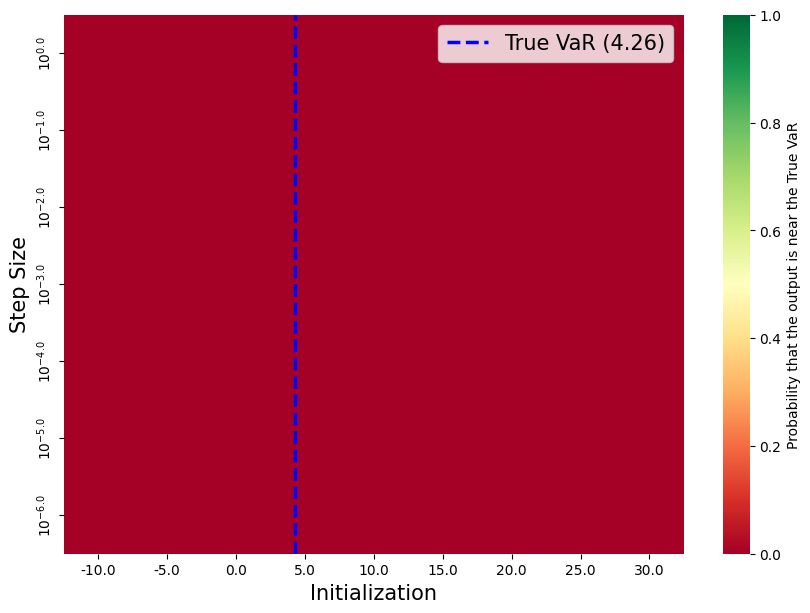

In [6]:
# exp_heatmap_config["tolerance"] = 0.5
plot_heatmap(res_heatmap_std["heatmap"], exp_heatmap_config, algo_config_std)

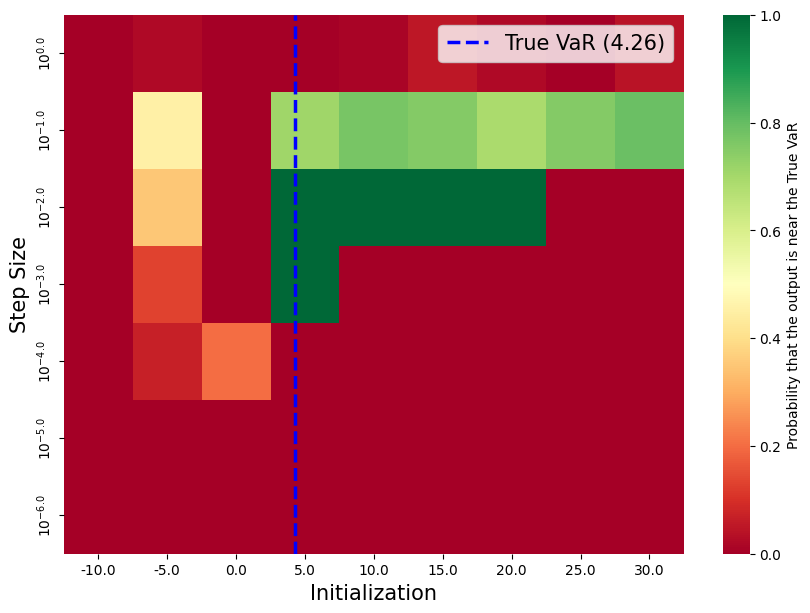

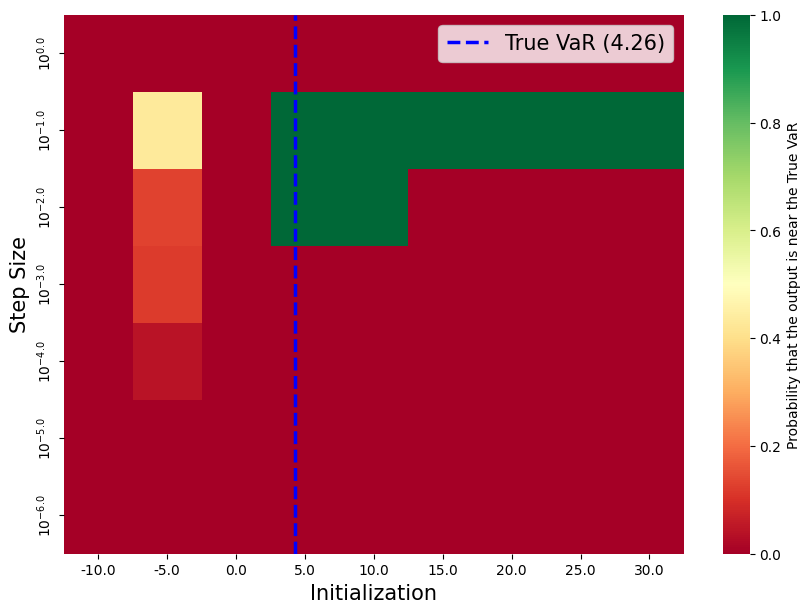

In [7]:

plot_heatmap(res_heatmap_const_last["heatmap"], exp_heatmap_config, algo_const_last)
plot_heatmap(res_heatmap_dim_avg["heatmap"], exp_heatmap_config, algo_dim_avg)


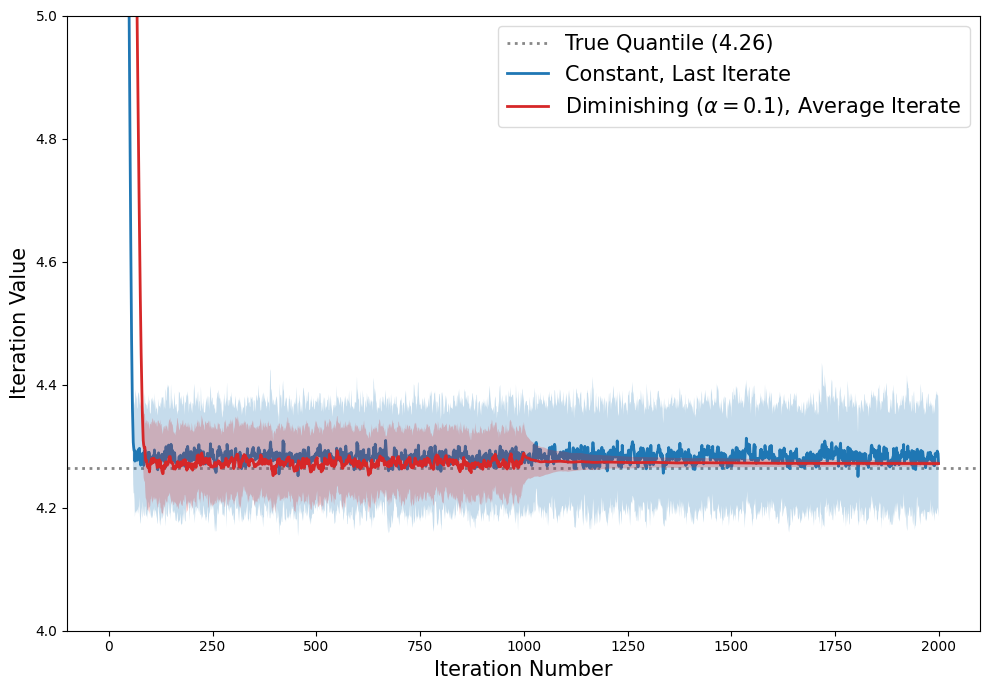

In [8]:
# 3. Plot the Trajectories
# init_grid is length 10. Index 5 is theta_0 = 10.0 (A Safe Start)
# lr_grid is length 9. Index 4 is a mid-range step size (10^-2)
TARGET_LR_IDX = 5
TARGET_INIT_IDX = 4

trajectory_configs = [
     {
        'data': res_heatmap_const_last['trajectories'],
        'lr_idx': TARGET_LR_IDX,
        'init_idx': TARGET_INIT_IDX,
        'label': 'Constant, Last Iterate',
        'color': '#1f77b4'  # Muted Blue: Good for the noisy baseline
    },

     {
        'data': res_heatmap_dim_avg['trajectories'],
        'lr_idx': TARGET_LR_IDX,
        'init_idx': TARGET_INIT_IDX,
        'label': r'Diminishing ($\alpha=0.1$), Average Iterate',
        'color': '#d62728'  # Bold Red: The theoretical winner, draws the eye
    }
]

# Note: If your plot_trajectories function supports zorder,
# make sure the red line is plotted with the highest zorder so it isn't hidden!
plot_trajectories(trajectory_configs, exp_heatmap_config, y_lim=(4.0, 5.0))

In [ ]:
TARGET_LR_IDX = 5
TARGET_INIT_IDX = 4

exp_heatmap_config_extra = exp_heatmap_config.copy()

exp_heatmap_config_extra['init_grid'] = INIT_GRID[[TARGET_INIT_IDX]]
exp_heatmap_config_extra['lr_grid'] = LR_GRID[[TARGET_LR_IDX]]

In [ ]:


algo_config_std_extra = {
    'variance_reduce': False,
    'scheme': 'constant',
    'alpha': .0,
    'init_multiplier': 1.0,
    'iterations': 2000,       # Iteration budget moved here,
    'batch_size': 100000
}

# Run the configurations
res_heatmap_std_extra = run_exp(exp_heatmap_config_extra, algo_config_std_extra)

Running | VR: False | Scheme: constant | Iterations: 2000 | Burn-in: 1000


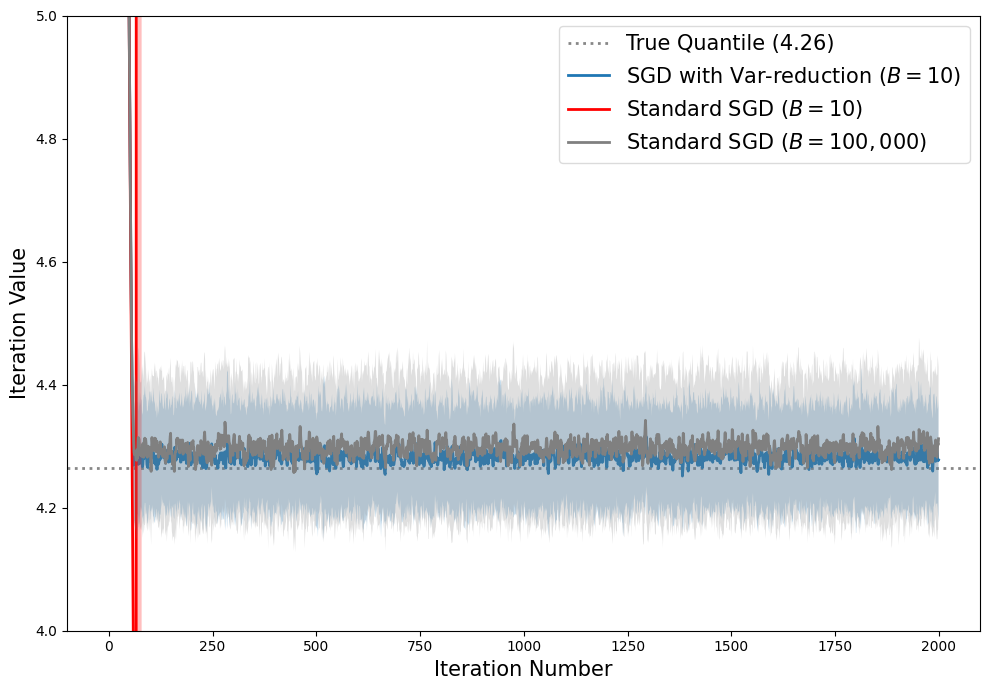

In [ ]:
# 3. Plot the Trajectories
# For Panel C (Theorem 3: Variance Reduction)
TARGET_LR_IDX = 5
TARGET_INIT_IDX = 4

trajectory_configs = [
    {
        'data': res_heatmap_const_last['trajectories'],
        'lr_idx': TARGET_LR_IDX,
        'init_idx': TARGET_INIT_IDX,
        'label': r'SGD with Var-reduction $(B=10)$',
        'color': '#1f77b4'  # Blue: The standard control baseline
    },
    {
        'data': res_heatmap_std['trajectories'],
        'lr_idx': TARGET_LR_IDX,
        'init_idx': TARGET_INIT_IDX,
        'label': r'Standard SGD $(B=10)$',
        'color': 'red'      # Red: Screams "Danger/Failure" for the massive variance
    },
    {
        'data': res_heatmap_std_extra['trajectories'],
        'lr_idx': 0,
        'init_idx': 0,
        'label': r'Standard SGD $(B=100,000)$',
        'color': 'gray'     # Gray: Represents a dull, brute-force baseline
    }
]

# Note: If your plot_trajectories function supports zorder,
# plot Gray first (lowest), then Blue, then Red (highest) so the explosion is visible!
plot_trajectories(trajectory_configs, exp_heatmap_config, y_lim=(4., 5.0))

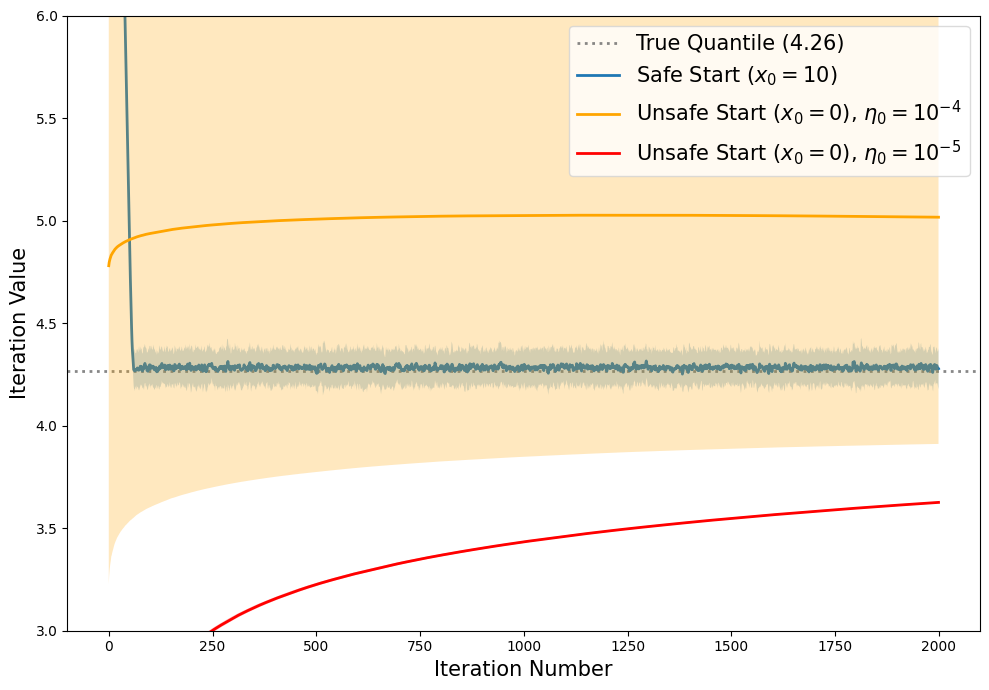

In [ ]:
# 3. Plot the Trajectories
# init_grid is length 10. Index 5 is theta_0 = 10.0 (A Safe Start)
# lr_grid is length 9. Index 4 is a mid-range step size (10^-2)
TARGET_LR_IDX = 5
TARGET_INIT_IDX = 4

trajectory_configs = [
    {
        'data': res_heatmap_const_last['trajectories'],
        'lr_idx': TARGET_LR_IDX,
        'init_idx': TARGET_INIT_IDX,
        'label': r'Safe Start ($x_0=10$)',
        'color': '#1f77b4'  # Muted Blue: The Control
    },
    {
        'data': res_heatmap_const_last['trajectories'],
        'lr_idx': 2,
        'init_idx': 2,
        'label': r'Unsafe Start ($x_0=0$), $\eta_0=10^{-4}$',
        'color': 'orange'   # Orange: The Explosive Failure
    },
    {
        'data': res_heatmap_const_last['trajectories'],
        'lr_idx': 1,
        'init_idx': 2,
        'label': r'Unsafe Start ($x_0=0$), $\eta_0=10^{-5}$',
        'color': 'red'      # Red: The Starvation Failure
    }
]

# Note: If your plot_trajectories function supports zorder,
# make sure the red line is plotted with the highest zorder so it isn't hidden!
plot_trajectories(trajectory_configs, exp_heatmap_config, y_lim=(3.0, 6.0))

# CVaR of derivative

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import root_scalar
import warnings

# Suppress overflow warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Configuration Dictionaries
# ==========================================

exp_config = {
    'q': 0.99999,
    'n_runs': 10,            # Reduced slightly from 100 for IS root-finding speed, increase if needed
    'batch_size': 20,
    'tolerance': 20.0,        # Increased tolerance due to portfolio scale (True VaR approx 214-233)
    'init_grid': np.linspace(0, 600, 10),
    'lr_grid': np.logspace(-2, 1, 8),
    'clip_val': 40000
}

algo_config_std = {
    'variance_reduce': False,
    'scheme': 'constant',
    'alpha': 0.5,
    'init_multiplier': 1.0,
    'iterations': 2000
}

algo_config_is = {
    'variance_reduce': True,
    'scheme': 'avg',         # Diminishing average-iterate scheme
    'alpha': 0.1,
    'init_multiplier': 1.0,
    'iterations': 2000,
    'burn_in_fraction': 0.5
}

# ==========================================
# 2. Financial Mechanics & IS Generators
# ==========================================

def bs_price_greeks(S, K, r, q_div, sigma, tau):
    """Vectorized Black-Scholes price and Greeks (Theta, Delta, Gamma)."""
    d1 = (np.log(S / K) + (r - q_div + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)

    # Prices
    c = S * np.exp(-q_div * tau) * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    p = K * np.exp(-r * tau) * norm.cdf(-d2) - S * np.exp(-q_div * tau) * norm.cdf(-d1)

    # Delta
    delta_c = np.exp(-q_div * tau) * norm.cdf(d1)
    delta_p = -np.exp(-q_div * tau) * norm.cdf(-d1)

    # Gamma (identical for call and put)
    gamma = np.exp(-q_div * tau) * norm.pdf(d1) / (S * sigma * np.sqrt(tau))

    # Theta (formatted to match MATLAB benchmark exactly)
    theta_c = (-np.exp(-q_div*tau) * S * norm.pdf(d1) * sigma / (2*np.sqrt(tau))
               - r*K*np.exp(-r*tau)*norm.cdf(d2) + q_div*S*np.exp(-q_div*tau)*norm.cdf(d1))
    theta_p = (-np.exp(-q_div*tau) * S * norm.pdf(-d1) * sigma / (2*np.sqrt(tau))
               + r*K*np.exp(-r*tau)*norm.cdf(-d2) - q_div*S*np.exp(-q_div*tau)*norm.cdf(-d1))

    return c, p, delta_c, delta_p, gamma, theta_c, theta_p

def setup_portfolio():
    """Generates the quadratic approximation constants (b, lambda, etc.) for the portfolio."""
    S = 100.0; K = 100.0; r = 0.05; q_div = 0.0; sigma = 0.3; T = 0.5; deltaT = 0.04

    c0, p0, dc, dp, gam, tc, tp = bs_price_greeks(S, K, r, q_div, sigma, T)
    Phi0 = (-10 * c0 - 5 * p0) * 10

    a0 = -(-10 * tc - 5 * tp) * 10 * deltaT
    a = -(-10 * dc - 5 * dp) * np.ones(10)
    A = -0.5 * np.diag((-10 * gam - 5 * gam) * np.ones(10))

    Sigma = np.diag((S * sigma)**2 * np.ones(10) * deltaT)
    evals_Sigma, evecs_Sigma = np.linalg.eigh(Sigma)
    Ctil = evecs_Sigma @ np.diag(np.sqrt(evals_Sigma))

    evals_A, U = np.linalg.eigh(Ctil.T @ A @ Ctil)
    lambdas = evals_A
    C = Ctil @ U
    b = C.T @ a

    return S, K, r, q_div, sigma, T, deltaT, Phi0, a0, lambdas, b, Ctil

def phi_f(theta, lambdas, b):
    """CGF of the quadratic approximation."""
    return -0.5 * np.sum(np.log(1 - 2 * theta * lambdas)) + 0.5 * np.sum((theta**2 * b**2) / (1 - 2 * theta * lambdas))

def phi_prime(theta, lambdas, b, target_q, a0):
    """Derivative of the CGF used for root finding."""
    return np.sum(lambdas / (1 - 2 * theta * lambdas)) + np.sum((theta * b**2) / (1 - 2 * theta * lambdas)**2) + a0 - target_q

def find_is_parameter(x_target, lambdas, b, a0):
    """Solves for the optimal IS twist parameter given the current VaR threshold x."""
    max_theta = 1 / (2 * np.max(lambdas)) - 1e-6
    try:
        # Find root using scipy
        res = root_scalar(lambda th: phi_prime(th, lambdas, b, x_target, a0),
                          bracket=[0, max_theta], method='brentq')
        return res.root
    except ValueError:
        # Fallback if bounds do not contain root (usually if x_target is not extremely deep in tail)
        return 0.0

# ==========================================
# 3. Experiment Execution Engine
# ==========================================

def run_exp(exp_config, algo_config):
    """Runs the SGD simulation tailored for the high-dimensional CVaR problem."""
    q_target = exp_config['q']

    true_var = exp_config["true_var"]
    n_runs = exp_config['n_runs']
    batch_size = exp_config['batch_size']
    tolerance = exp_config['tolerance']
    clip_val = exp_config['clip_val']

    init_grid = exp_config['init_grid']
    lr_grid = exp_config['lr_grid']

    variance_reduce = algo_config['variance_reduce']
    scheme = algo_config.get('scheme', 'last')
    alpha = algo_config['alpha']
    init_multiplier = algo_config['init_multiplier']
    iterations = algo_config['iterations']
    burn_in_steps = int(iterations * algo_config.get('burn_in_fraction', 0.5))

    # Portfolio Setup
    S, K, r, q_div, sigma, T, deltaT, Phi0, a0, lambdas, b, Ctil = setup_portfolio()

    heatmap_results = np.zeros((len(lr_grid), len(init_grid)))
    trajectories = np.zeros((len(lr_grid), len(init_grid), iterations, n_runs))

    print(f"Running | VR: {variance_reduce} | Scheme: {scheme} | Iterations: {iterations}")

    for i, lr_base in enumerate(lr_grid):
        print("iteration lr", i, lr_base)
        for j, init_val_base in enumerate(init_grid):

            x_var = np.full(n_runs, init_val_base)

            weighted_sum_x = np.zeros(n_runs)
            sum_eta = 0.0

            for t in range(iterations):
                lr_t = lr_base * (1 + t)**(-alpha) * init_multiplier
                grad = np.zeros(n_runs)

                # Z base shape: (n_runs, batch_size, 10 underlying assets)
                Z = np.random.randn(n_runs, batch_size, 10)

                for run_idx in range(n_runs):
                    if variance_reduce:
                        # 1. Compute state-dependent IS parameter for current x_var
                        is_th = find_is_parameter(x_var[run_idx], lambdas, b, a0)

                        # 2. Twist distribution
                        phi_val = phi_f(is_th, lambdas, b)
                        sigma2_new = 1.0 / (1 - 2 * is_th * lambdas)
                        mu_new = is_th * b * sigma2_new

                        # 3. Apply twist to standard normals
                        Z_twisted = mu_new + np.sqrt(sigma2_new) * Z[run_idx] # Shape: (batch_size, 10)

                        # 4. Price exactly on twisted distribution
                        S_tau = S + Z_twisted @ Ctil.T
                        c_tau, p_tau, _, _, _, _, _ = bs_price_greeks(S_tau, K, r, q_div, sigma, T - deltaT)
                        Phim = -10 * c_tau - 5 * p_tau
                        Phi = np.sum(Phim, axis=1) # Sum across the 10 assets
                        Loss = Phi0 - Phi

                        # 5. Compute Likelihood Ratio
                        # Note: X_quad approximates the loss for the LR calculation
                        X_quad = (Z_twisted @ b) + np.sum(Z_twisted * (Z_twisted * lambdas), axis=1)
                        LR = np.exp(-is_th * X_quad + phi_val)

                        # 6. CVaR Gradient
                        indicator = (Loss > x_var[run_idx]).astype(float)
                        grad[run_idx] = 1 - (1 / (1 - q_target)) * np.mean(indicator * LR)

                    else:
                        # Standard Monte Carlo
                        S_tau = S + Z[run_idx] @ Ctil.T
                        c_tau, p_tau, _, _, _, _, _ = bs_price_greeks(S_tau, K, r, q_div, sigma, T - deltaT)
                        Phim = -10 * c_tau - 5 * p_tau
                        Phi = np.sum(Phim, axis=1)
                        Loss = Phi0 - Phi

                        indicator = (Loss > x_var[run_idx]).astype(float)
                        grad[run_idx] = 1 - (1 / (1 - q_target)) * np.mean(indicator)

                # Update and clip
                x_var = x_var - lr_t * grad
                x_var = np.clip(x_var, -clip_val, clip_val)

                # Tracking Logic
                if scheme == 'avg':
                    if t >= burn_in_steps:
                        weighted_sum_x += lr_t * x_var
                        sum_eta += lr_t
                        current_track = weighted_sum_x / sum_eta
                    else:
                        current_track = x_var
                else:
                    current_track = x_var

                trajectories[i, j, t, :] = current_track

            # Calculate Success Probabilities
            final_iterate = trajectories[i, j, -1, :]
            success = np.mean(np.abs(final_iterate - true_var) <= tolerance)
            heatmap_results[i, j] = success

    return {
        "heatmap": heatmap_results,
        "trajectories": trajectories
    }

In [3]:
np.logspace(-6, 6, 6)

array([1.00000000e-06, 2.51188643e-04, 6.30957344e-02, 1.58489319e+01,
       3.98107171e+03, 1.00000000e+06])

In [4]:
exp_config = {
    'q': 0.99999,
    'n_runs': 50,
    'batch_size': 10,
    'tolerance': 10.0,
    'true_var': 382,
    # Focus the grid tightly around the VaR to test the immediate landscape
    'init_grid': np.linspace(0, 800, 5),
    # Use larger step sizes capable of traversing the distance
    'lr_grid': np.logspace(-2, 2, 5),
    'clip_val': 40000
}

algo_config_std = {
    'variance_reduce': False,
    'scheme': 'last',        # Keep to last iterate for MC baseline
    'alpha': 0.0,            # Force CONSTANT step size
    'init_multiplier': 1.0,
    'iterations': 500      # 5x the iterations to allow safe starts to walk down
}

algo_avg_is = {
    'variance_reduce': True,
    'scheme': 'avg',
    'alpha': 0.1,            # Diminishing step size
    'init_multiplier': 1.0,
    'iterations': 500,     # Give the average iterate time to settle
    'burn_in_fraction': 0.2  # Start averaging sooner
}

algo_last_is = {
    'variance_reduce': True,
    'scheme': 'last',         # Diminishing average-iterate scheme
    'alpha': 0.0,
    'init_multiplier': 1.0,
    'iterations': 500,
    'burn_in_fraction': 0.5
}

In [5]:
# res_finance_avg = run_exp(exp_config, algo_avg_is)
res_finance_last = run_exp(exp_config, algo_last_is)
# res_finance_std = run_exp(exp_config, algo_config_std)
res_finance_std = run_exp(exp_config, algo_config_std)
res_finance_avg = run_exp(exp_config, algo_avg_is)

Running | VR: True | Scheme: last | Iterations: 500
iteration lr 0 0.01
iteration lr 1 0.1


KeyboardInterrupt: 

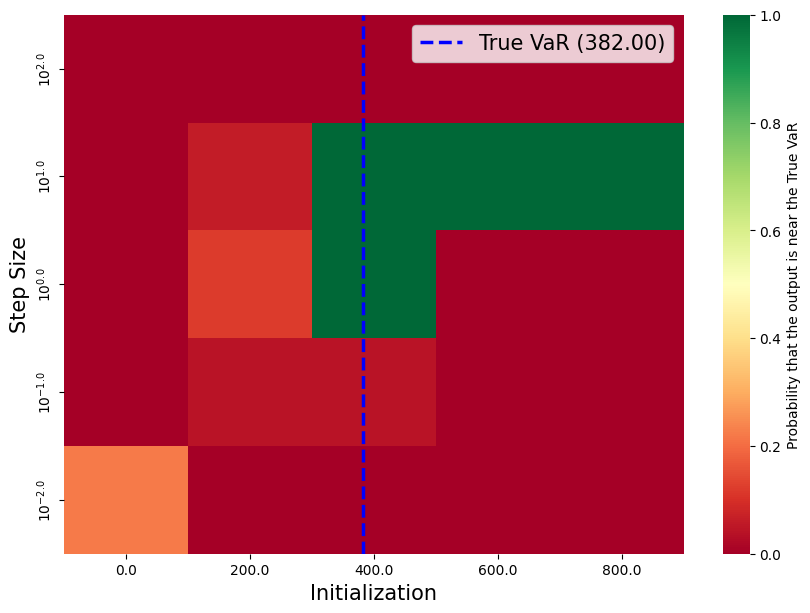

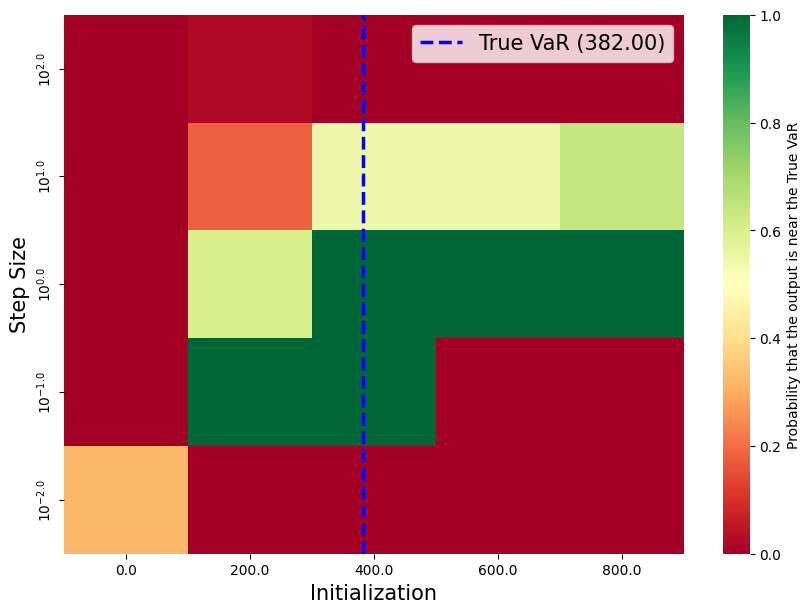

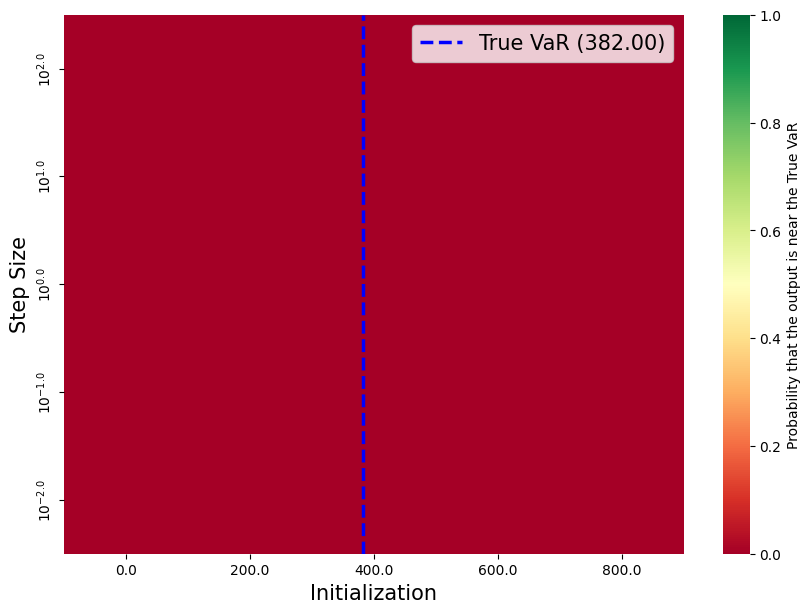

In [ ]:
plot_heatmap(res_finance_avg["heatmap"], exp_config, algo_avg_is, true_var= 382)
plot_heatmap(res_finance_last["heatmap"], exp_config, algo_last_is, true_var= 382)
plot_heatmap(res_finance_std["heatmap"], exp_config, algo_config_std, true_var= 382)

In [ ]:
# 2. Empirical SAA Evaluation
def debug_naive_mc_saa(n_samples=1_000_000, q=0.99999):
    print(f"Generating {n_samples:,} samples for Naive MC SAA...")

    # Fetch portfolio setup
    S, K, r, q_div, sigma, T, deltaT, Phi0, a0, lambdas, b, Ctil = setup_portfolio()

    # Generate standard normals
    Z = np.random.randn(n_samples, 10)

    # Apply covariance structure (Ctil) to simulate underlying asset jumps
    S_tau = S + Z @ Ctil.T

    # Evaluate Black-Scholes prices at the new horizon (T - deltaT)
    c_tau, p_tau, _, _, _, _, _ = bs_price_greeks(S_tau, K, r, q_div, sigma, T - deltaT)

    # Calculate portfolio value at tau across all samples
    Phim = -10 * c_tau - 5 * p_tau
    Phi = np.sum(Phim, axis=1) # Sum across the 10 assets

    # Calculate the exact loss
    Loss = Phi0 - Phi

    # Evaluate empirical quantile
    empirical_var = np.quantile(Loss, q)
    max_loss = np.max(Loss)

    print("-" * 30)
    print(f"Target q:            {q}")
    print(f"Empirical VaR (SAA): {empirical_var:.4f}")
    print(f"Maximum Loss Seen:   {max_loss:.4f}")
    print("-" * 30)

    return Loss, empirical_var

# Execute the debugger
if __name__ == "__main__":
    # Adjust n_samples based on your machine's memory limit. 1e6 to 1e7 is ideal.
    L, var_estimate = debug_naive_mc_saa(n_samples=1_0000_000, q=0.99999)

Generating 10,000,000 samples for Naive MC SAA...
------------------------------
Target q:            0.99999
Empirical VaR (SAA): 382.3829
Maximum Loss Seen:   489.2966
------------------------------


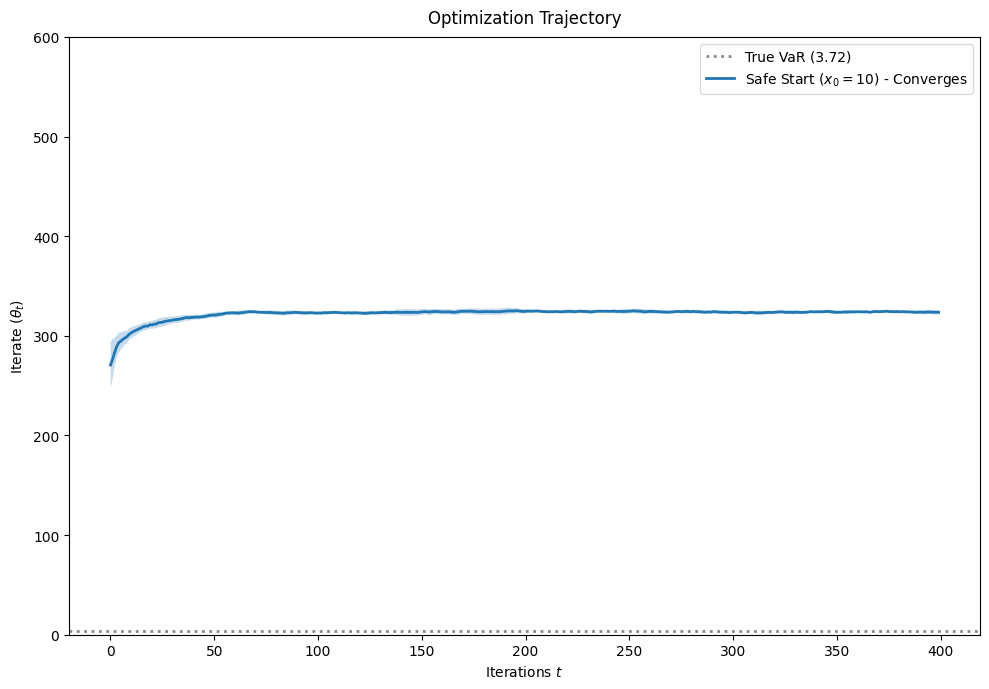

In [ ]:

TARGET_LR_IDX = 2
TARGET_INIT_IDX = 0

trajectory_configs = [
    {
        'data': res_finance_last['trajectories'],
        'lr_idx': TARGET_LR_IDX,
        'init_idx': TARGET_INIT_IDX,
        'label': r'Safe Start ($x_0=10$) - Converges',
        'color': '#1f77b4'  # Muted Blue: The Control
    },

]

# Note: If your plot_trajectories function supports zorder,
# make sure the red line is plotted with the highest zorder so it isn't hidden!
plot_trajectories(trajectory_configs, exp_config, y_lim=(0.0, 600.0))

In [ ]:
res_finance_last['trajectories'][2][0]

array([[284.90377811],
       [288.35925785],
       [287.35925785],
       [290.90709124],
       [292.27070289],
       [291.58161465],
       [300.11378364],
       [301.86386064],
       [301.30596107],
       [301.81109826],
       [303.55797487],
       [302.72581871],
       [304.61134719],
       [304.04322705],
       [303.35507461],
       [304.83798995],
       [305.23394129],
       [306.88168119],
       [309.49109234],
       [310.68233381],
       [309.68233381],
       [309.45330198],
       [308.45330198],
       [308.28215095],
       [308.85508391],
       [309.39282271],
       [312.59271358],
       [313.09008148],
       [312.15426732],
       [315.92727697],
       [318.26116311],
       [317.275056  ],
       [316.67228977],
       [317.05253997],
       [319.04813856],
       [319.80501244],
       [319.33160042],
       [319.18493288],
       [319.77137452],
       [319.19612413],
       [318.51450415],
       [319.93552403],
       [320.41745416],
       [320

# Multi Dimension Setting

In [3]:
# ============================================================
# Multi-dimensional CVaR: N assets ~ N(mu, Sigma), decision = (w, eta)
#   Loss L(w) = -w^T R ;  F(w,eta) = eta + 1/(1-q) E[(L-eta)^+]
# ------------------------------------------------------------
# 1. Instance + EXACT objective and optimum (no simulation)
# ============================================================
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def make_instance(n=10, seed=0):
    rng = np.random.default_rng(seed)
    # mu = -1.8 + 1.0*rng.standard_normal(n)
    mu = 0 + 1.0*rng.standard_normal(n)
    vol  = 0.8+ 0.8*rng.random(n)                   # per-asset vols
    Corr = 0.4*np.ones((n,n)) + 0.6*np.eye(n)          # 0.2 baseline correlation
    Sigma = np.outer(vol, vol)*Corr
    return mu, 0.5*(Sigma+Sigma.T)

def cvar_objective(w, eta, mu, Sigma, q):
    """Exact RU-CVaR objective (Gaussian closed form). Use this to SCORE iterates."""
    m = -w @ mu
    s = np.sqrt(max(w @ Sigma @ w, 1e-18))
    u = (m - eta)/s
    return eta + (1.0/(1.0-q))*((m-eta)*norm.cdf(u) + s*norm.pdf(u))

def cvar_star(mu, Sigma, q, long_only=True):
    """Ground truth: min_w -mu^T w + k_q sqrt(w^T Sigma w) s.t. 1^T w = 1."""
    n = len(mu); k = norm.pdf(norm.ppf(q))/(1.0-q)
    obj  = lambda w: -mu @ w + k*np.sqrt(max(w @ Sigma @ w, 1e-18))
    cons = [{'type':'eq','fun': lambda w: np.sum(w)-1.0}]
    bnds = [(0,None)]*n if long_only else None
    w = minimize(obj, np.ones(n)/n, method='SLSQP', bounds=bnds,
                 constraints=cons, options={'ftol':1e-12,'maxiter':500}).x
    eta = -w @ mu + norm.ppf(q)*np.sqrt(w @ Sigma @ w)
    return w, eta, cvar_objective(w, eta, mu, Sigma, q)

In [4]:
# ============================================================
# 2. Projection, stochastic gradient (plain MC / Gaussian IS), one SGD run
# ============================================================
def project_simplex(v):
    """Euclidean projection onto {w >= 0, 1^T w = 1}."""
    u = np.sort(v)[::-1]; css = np.cumsum(u)
    rho = np.nonzero(u*np.arange(1,len(v)+1) > (css-1))[0][-1]
    return np.maximum(v - (css[rho]-1)/(rho+1.0), 0)

def run_sgd(mu, Sigma, q, w0, eta0, lr, T, B, alpha, use_is, avg, seed):
    rng = np.random.default_rng(seed)
    L_chol = np.linalg.cholesky(Sigma); Sinv = np.linalg.inv(Sigma)
    w = w0.copy(); eta = float(eta0)
    wsum = np.zeros_like(w); esum = 0.0; wt = 0.0
    for t in range(T):
        lr_t = lr*(1+t)**(-alpha)
        if use_is:                                     # LD-optimal mean shift along Sigma w
            sw2 = w @ Sigma @ w
            shift = ((-eta - w @ mu)/sw2)*(Sigma @ w)
            R = (mu+shift) + rng.standard_normal((B,len(w))) @ L_chol.T
            LR = np.exp(-(R-mu) @ (Sinv @ shift) + 0.5*shift @ (Sinv @ shift))
        else:
            R = mu + rng.standard_normal((B,len(w))) @ L_chol.T
            LR = np.ones(B)
        L   = -(R @ w)
        ind = (L > eta).astype(float)*LR
        g_eta = 1.0 - (1.0/(1.0-q))*ind.mean()
        g_w   = (1.0/(1.0-q))*((ind[:,None]*(-R)).mean(axis=0))
        w   = project_simplex(w - lr_t*g_w)
        eta = eta - lr_t*g_eta
        if avg and t >= T//2:
            wsum += lr_t*w; esum += lr_t*eta; wt += lr_t

    
    return (wsum/wt, esum/wt) if (avg and wt>0) else (w, eta)

In [26]:
# ============================================================
# 3. Experiment: two fixed inits (safe / unsafe) x step-size grid -> success table
#    success := F(x_hat) <= (1+eps) F*   (exact objective)
# ============================================================
def experiment(n=10, q=0.99999, B=256, T=500, alpha=0.2, eps=0.05, n_seeds=8,
               use_is=True, avg=True, seed=0, lr_grid=None):
    mu, Sigma = make_instance(n, seed)
    w_star, eta_star, F_star = cvar_star(mu, Sigma, q)
    w0 = np.ones(n)/n
    var_ew = -w0 @ mu + norm.ppf(q)*np.sqrt(w0 @ Sigma @ w0)
    inits = {'SAFE  (eta0=2.0 VaR_ew)': (w0, 2.*var_ew),      # tail penalty ~ 0
             'UNSAFE(eta0=mean loss) ': (w0, -w0 @ mu)}        # tail penalty huge
    if lr_grid is None: lr_grid = np.logspace(-6, 3.0, 10)
    print(f"n={n} q={q} F*={F_star:.4f} eta*={eta_star:.4f} VaR_ew={var_ew:.4f} "
          f"IS={use_is} avg={avg} B={B} T={T} eps={eps}  target={(1+eps)*F_star:.4f}  mean loss={(-w0 @ mu):.4f}")
    print(" ".ljust(24) + "".join(f"{lr:9.2g}" for lr in lr_grid))
    for name,(wi,ei) in inits.items():
        row = name.ljust(24)
        for lr in lr_grid:
            succ = sum(cvar_objective(*run_sgd(mu,Sigma,q,wi,ei,lr,T,B,alpha,use_is,avg,1000*s+7),
                                      mu,Sigma,q) <= (1+eps)*F_star for s in range(n_seeds))
            row += f"{succ/n_seeds:9.2f}"
        print(row)
    return F_star

# ---- run it ----
print("=== plain SGD (no variance reduction) ===");  experiment(n_seeds = 100,avg = False, use_is=False)
print("\n=== SGD + Gaussian IS (variance reduction) ==="); experiment(n_seeds = 100,avg = False,use_is=True)

=== plain SGD (no variance reduction) ===
n=10 q=0.99999 F*=2.7831 eta*=2.6377 VaR_ew=3.3372 IS=False avg=False B=256 T=500 eps=0.05  target=2.9222  mean loss=-0.0847
                            1e-06    1e-05   0.0001    0.001     0.01      0.1        1       10    1e+02    1e+03
SAFE  (eta0=2.0 VaR_ew)      0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
UNSAFE(eta0=mean loss)       0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00

=== SGD + Gaussian IS (variance reduction) ===
n=10 q=0.99999 F*=2.7831 eta*=2.6377 VaR_ew=3.3372 IS=True avg=False B=256 T=500 eps=0.05  target=2.9222  mean loss=-0.0847
                            1e-06    1e-05   0.0001    0.001     0.01      0.1        1       10    1e+02    1e+03
SAFE  (eta0=2.0 VaR_ew)      0.00     0.00     0.00     0.00     0.00     1.00     0.98     0.00     0.00     0.00
UNSAFE(eta0=mean loss)       0.00     0.00     0.00     0.00     0.00     0.00     0.0

np.float64(2.7830761910837505)

F*=2.7831  eta*=2.6377  VaR_ew=3.3372  target=(1+eps)F*  lr=1.0  B=128 T=500
saved cvar_trajectories.png


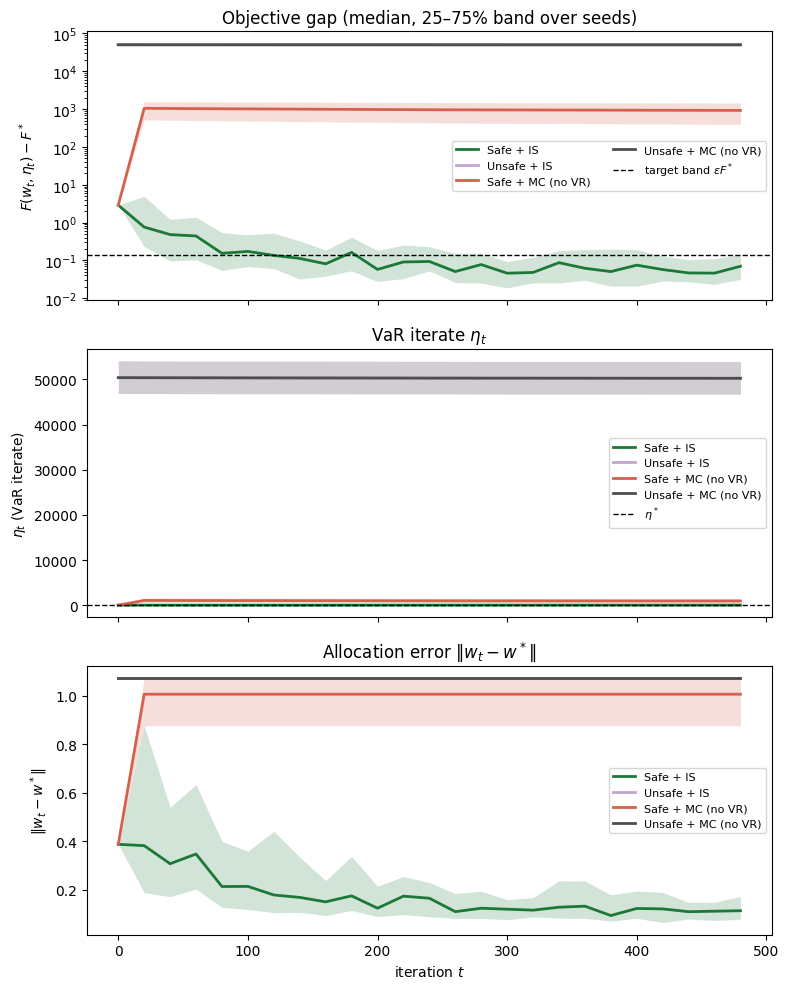

In [24]:
"""
CVaR portfolio optimization: trajectory diagnostics with seed bands.

Produces three stacked panels (median + interquantile band over seeds):
  (1) objective gap   F(w_t, eta_t) - F*      [log y]  <- the headline
  (2) VaR iterate     eta_t   (with eta* line)          <- overshoot mechanism
  (3) allocation err  ||w_t - w*||                       <- the vector part

Each panel overlays the four configurations:
  SAFE+IS, UNSAFE+IS, SAFE+MC, UNSAFE+MC
"""

import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# instance + exact objective / ground truth (your definitions)
# ------------------------------------------------------------
def make_instance(n=10, seed=0):
    rng = np.random.default_rng(seed)
    mu = 0 + 1.0 * rng.standard_normal(n)
    vol = 0.8 + 0.8 * rng.random(n)
    Corr = 0.4 * np.ones((n, n)) + 0.6 * np.eye(n)
    Sigma = np.outer(vol, vol) * Corr
    return mu, 0.5 * (Sigma + Sigma.T)

def cvar_objective(w, eta, mu, Sigma, q):
    """Exact R-U CVaR objective (Gaussian closed form)."""
    m = -w @ mu
    s = np.sqrt(max(w @ Sigma @ w, 1e-18))
    u = (m - eta) / s
    return eta + (1.0 / (1.0 - q)) * ((m - eta) * norm.cdf(u) + s * norm.pdf(u))

def cvar_star(mu, Sigma, q, long_only=True):
    n = len(mu); k = norm.pdf(norm.ppf(q)) / (1.0 - q)
    obj = lambda w: -mu @ w + k * np.sqrt(max(w @ Sigma @ w, 1e-18))
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    bnds = [(0, None)] * n if long_only else None
    w = minimize(obj, np.ones(n)/n, method='SLSQP', bounds=bnds,
                 constraints=cons, options={'ftol': 1e-12, 'maxiter': 500}).x
    eta = -w @ mu + norm.ppf(q) * np.sqrt(w @ Sigma @ w)
    return w, eta, cvar_objective(w, eta, mu, Sigma, q)

# ------------------------------------------------------------
# projection + SGD that LOGS a trajectory
# ------------------------------------------------------------
def project_simplex(v):
    u = np.sort(v)[::-1]; css = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(v)+1) > (css - 1))[0][-1]
    return np.maximum(v - (css[rho] - 1) / (rho + 1.0), 0)

def run_sgd_logged(mu, Sigma, q, w0, eta0, lr, T, B, alpha,
                   use_is, avg, seed, w_star, F_star, log_every=1):
    """Same SGD as before, but returns per-step logs of (F_gap, eta, w_err)."""
    rng = np.random.default_rng(seed)
    L_chol = np.linalg.cholesky(Sigma); Sinv = np.linalg.inv(Sigma)
    w = w0.copy(); eta = float(eta0)
    wsum = np.zeros_like(w); esum = 0.0; wt = 0.0

    ts, gaps, etas, werrs = [], [], [], []
    for t in range(T):
        lr_t = lr * (1 + t) ** (-alpha)
        if use_is:
            sw2 = w @ Sigma @ w
            shift = ((-eta - w @ mu) / sw2) * (Sigma @ w)
            R = (mu + shift) + rng.standard_normal((B, len(w))) @ L_chol.T
            LR = np.exp(-(R - mu) @ (Sinv @ shift) + 0.5 * shift @ (Sinv @ shift))
        else:
            R = mu + rng.standard_normal((B, len(w))) @ L_chol.T
            LR = np.ones(B)
        L = -(R @ w)
        ind = (L > eta).astype(float) * LR
        g_eta = 1.0 - (1.0 / (1.0 - q)) * ind.mean()
        g_w = (1.0 / (1.0 - q)) * ((ind[:, None] * (-R)).mean(axis=0))
        w = project_simplex(w - lr_t * g_w)
        eta = eta - lr_t * g_eta

        # choose which iterate to REPORT (averaged tail if avg=True)
        if avg and t >= T // 2:
            wsum += lr_t * w; esum += lr_t * eta; wt += lr_t
            w_rep = wsum / wt; eta_rep = esum / wt
        else:
            w_rep, eta_rep = w, eta

        if t % log_every == 0:
            F = cvar_objective(w_rep, eta_rep, mu, Sigma, q)
            ts.append(t)
            gaps.append(F - F_star)
            etas.append(eta_rep)
            werrs.append(np.linalg.norm(w_rep - w_star))

    return np.array(ts), np.array(gaps), np.array(etas), np.array(werrs)

# ------------------------------------------------------------
# run many seeds for one config -> stacked arrays for banding
# ------------------------------------------------------------
def collect(mu, Sigma, q, w0, eta0, lr, T, B, alpha, use_is, avg,
            w_star, F_star, n_seeds, log_every):
    G, E, W = [], [], []
    for s in range(n_seeds):
        ts, g, e, wr = run_sgd_logged(mu, Sigma, q, w0, eta0, lr, T, B, alpha,
                                      use_is, avg, 1000*s + 7, w_star, F_star, log_every)
        G.append(g); E.append(e); W.append(wr)
    return ts, np.vstack(G), np.vstack(E), np.vstack(W)

def band(ax, ts, M, color, label, lo=25, hi=75, logy=False):
    """median line + [lo,hi] percentile band across seeds; robust to non-finite."""
    M = np.where(np.isfinite(M), M, np.nan)
    med = np.nanmedian(M, axis=0)
    plo = np.nanpercentile(M, lo, axis=0)
    phi = np.nanpercentile(M, hi, axis=0)
    if logy:  # clip for log axis
        eps = 1e-12
        med = np.clip(med, eps, None); plo = np.clip(plo, eps, None); phi = np.clip(phi, eps, None)
    ax.plot(ts, med, color=color, label=label, lw=2)
    ax.fill_between(ts, plo, phi, color=color, alpha=0.20, linewidth=0)

# ------------------------------------------------------------
# main
# ------------------------------------------------------------
def main():
    n, q = 10, 0.99999
    B, T, alpha = 128, 500, 0.2
    n_seeds = 40
    log_every = 20
    lr = 1.            # single representative step size for the trajectory figure

    mu, Sigma = make_instance(n, seed=0)
    w_star, eta_star, F_star = cvar_star(mu, Sigma, q)
    w0 = np.ones(n) / n
    var_ew = -w0 @ mu + norm.ppf(q) * np.sqrt(w0 @ Sigma @ w0)

    eta_safe   = 2. * var_ew      # tail penalty ~ 0  -> safe
    eta_unsafe = -w0 @ mu          # tail penalty huge -> unsafe

    print(f"F*={F_star:.4f}  eta*={eta_star:.4f}  VaR_ew={var_ew:.4f}  "
          f"target=(1+eps)F*  lr={lr}  B={B} T={T}")

    configs = [
        # label,                eta0,        use_is, avg,  color
        ("Safe + IS",           eta_safe,    True,   False, "#1b7837"),
        ("Unsafe + IS",         eta_unsafe,  True,   False, "#c2a5cf"),
        ("Safe + MC (no VR)",   eta_safe,    False,  True,  "#d6604d"),
        ("Unsafe + MC (no VR)", eta_unsafe,  False,  True,  "#4d4d4d"),
    ]

    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    for label, eta0, use_is, avg, color in configs:
        ts, G, E, W = collect(mu, Sigma, q, w0, eta0, lr, T, B, alpha,
                              use_is, avg, w_star, F_star, n_seeds, log_every)
        band(axes[0], ts, G, color, label, logy=True)
        band(axes[1], ts, E, color, label)
        band(axes[2], ts, W, color, label)

    # (1) objective gap
    axes[0].set_yscale("log")
    axes[0].axhline(0.05 * F_star, ls="--", c="k", lw=1, label=r"target band $\varepsilon F^*$")
    axes[0].set_ylabel(r"$F(w_t,\eta_t) - F^*$")
    axes[0].set_title("Objective gap (median, 25–75% band over seeds)")
    axes[0].legend(fontsize=8, ncol=2)

    # (2) eta
    axes[1].axhline(eta_star, ls="--", c="k", lw=1, label=r"$\eta^*$")
    axes[1].set_ylabel(r"$\eta_t$ (VaR iterate)")
    axes[1].set_title(r"VaR iterate $\eta_t$")
    axes[1].legend(fontsize=8)

    # (3) ||w - w*||
    axes[2].set_ylabel(r"$\|w_t - w^*\|$")
    axes[2].set_title(r"Allocation error $\|w_t - w^*\|$")
    axes[2].set_xlabel("iteration $t$")
    axes[2].legend(fontsize=8)

    fig.tight_layout()
    # fig.savefig("/mnt/user-data/outputs/cvar_trajectories.png", dpi=150, bbox_inches="tight")
    print("saved cvar_trajectories.png")

if __name__ == "__main__":
    main()